# 04 — Counterfactual Emissions

What would Malaysia's power-sector CO2 have been over 2022–2024 if the fuel mix
had been different, holding total generation by region constant?

Three scenarios:

| Scenario | Coal | Gas | Hydro | Solar | Definition |
|---|---|---|---|---|---|
| `Baseline` | actual | actual | actual | actual | The observed 2022–2024 mix |
| `SarawakParity` | 13% | 19% | 65% | 3% | Sarawak's 2024 mix applied to every region |
| `NetZero2030Pathway` | 64.6%→30% | 19.1%→35% | 13.5%→25% | 2.8%→10% | Linear glide 2022→2030; only the 2022–2024 portion is realised here |

This holds each region's *total* monthly generation fixed and only re-slices it
across fuels. It is an upper bound on what fuel-mix change alone could deliver —
not a feasible policy pathway. See the caveat cell at the end.

In [1]:
import sqlite3
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DB = os.path.join("..", "malaysia_power.db")
OUT = os.path.join("..", "outputs")
os.makedirs(OUT, exist_ok=True)

con = sqlite3.connect(DB)
gen = pd.read_sql_query(
    """
    SELECT d.year, d.month, d.date_id, d.month_start,
           r.region_name, f.fuel_name, g.mwh, e.kg_co2_per_mwh
    FROM fact_generation_monthly g
    JOIN dim_date_month d   USING(date_id)
    JOIN dim_region r       USING(region_id)
    JOIN dim_fuel f         USING(fuel_id)
    JOIN emission_factor e  USING(fuel_id)
    """,
    con,
)
con.close()

FUELS = ["Coal", "Gas", "Hydro", "Solar"]
EF = gen.drop_duplicates("fuel_name").set_index("fuel_name")["kg_co2_per_mwh"].to_dict()
print("Emission factors (kg CO2 / MWh):", EF)
print("Rows:", len(gen), "| months:", gen.date_id.nunique(), "| regions:", gen.region_name.nunique())
gen.head()

Emission factors (kg CO2 / MWh): {'Coal': 940.0, 'Gas': 400.0, 'Hydro': 0.0, 'Solar': 0.0}
Rows: 396 | months: 36 | regions: 3


,year,month,date_id,month_start,region_name,fuel_name,mwh,kg_co2_per_mwh
0,2022,1,202201,2022-01-01,Peninsular,Coal,8279377.0,940.0
1,2022,1,202201,2022-01-01,Peninsular,Gas,1972341.0,400.0
2,2022,1,202201,2022-01-01,Peninsular,Hydro,523047.0,0.0
3,2022,1,202201,2022-01-01,Peninsular,Solar,445727.0,0.0
4,2022,1,202201,2022-01-01,Sabah,Gas,271382.0,400.0


In [2]:
# The envelope we hold constant: total generation per region per month.
env = (gen.groupby(["year", "month", "date_id", "month_start", "region_name"], as_index=False)["mwh"]
          .sum()
          .rename(columns={"mwh": "region_mwh"}))

# Actual fuel-mix shares per region/month (used by the Baseline scenario).
gen = gen.copy()
gen["share_actual"] = gen["mwh"] / gen.groupby(["year", "month", "region_name"])["mwh"].transform("sum")

# Fixed mixes.
SARAWAK_PARITY = {"Coal": 0.13, "Gas": 0.19, "Hydro": 0.65, "Solar": 0.03}

# NetZero2030: linear interpolation of the *national* mix from 2022 to 2030.
NZ_2022 = {"Coal": 0.646, "Gas": 0.191, "Hydro": 0.135, "Solar": 0.028}
NZ_2030 = {"Coal": 0.30,  "Gas": 0.35,  "Hydro": 0.25,  "Solar": 0.10}

def netzero_mix(year: int) -> dict:
    t = (year - 2022) / (2030 - 2022)
    return {f: NZ_2022[f] + t * (NZ_2030[f] - NZ_2022[f]) for f in FUELS}

for y in (2022, 2023, 2024):
    m = netzero_mix(y)
    print(f"NetZero2030 mix {y}: " + ", ".join(f"{f} {m[f]*100:.1f}%" for f in FUELS))

NetZero2030 mix 2022: Coal 64.6%, Gas 19.1%, Hydro 13.5%, Solar 2.8%
NetZero2030 mix 2023: Coal 60.3%, Gas 21.1%, Hydro 14.9%, Solar 3.7%
NetZero2030 mix 2024: Coal 56.0%, Gas 23.1%, Hydro 16.4%, Solar 4.6%


In [3]:
def scenario_long(name: str) -> pd.DataFrame:
    """Return a long frame: one row per (year, month, region, fuel) with mwh and co2_mt."""
    if name == "Baseline":
        df = gen[["year", "month", "date_id", "month_start", "region_name", "fuel_name", "mwh"]].copy()
    else:
        rows = []
        for _, e in env.iterrows():
            if name == "SarawakParity":
                mix = SARAWAK_PARITY
            elif name == "NetZero2030Pathway":
                mix = netzero_mix(int(e.year))
            else:
                raise ValueError(name)
            for f in FUELS:
                rows.append(dict(year=int(e.year), month=int(e.month), date_id=int(e.date_id),
                                 month_start=e.month_start, region_name=e.region_name,
                                 fuel_name=f, mwh=e.region_mwh * mix[f]))
        df = pd.DataFrame(rows)
    df["co2_mt"] = df["mwh"] * df["fuel_name"].map(EF) / 1e9   # kg -> Mt CO2
    df["scenario"] = name
    return df

SCENARIOS = ["Baseline", "SarawakParity", "NetZero2030Pathway"]
long = pd.concat([scenario_long(s) for s in SCENARIOS], ignore_index=True)

# Sanity: total generation must be identical across scenarios.
gen_check = long.groupby("scenario")["mwh"].sum()
assert np.allclose(gen_check.values, gen_check.iloc[0]), gen_check
print("Total generation identical across scenarios (TWh): %.1f" % (gen_check.iloc[0] / 1e6))

monthly = (long.groupby(["scenario", "year", "month", "month_start"], as_index=False)["co2_mt"].sum())
monthly["date"] = pd.to_datetime(monthly["month_start"])
annual = (long.groupby(["scenario", "year"], as_index=False)["co2_mt"].sum())
annual_wide = annual.pivot(index="year", columns="scenario", values="co2_mt")[SCENARIOS]
annual_wide.round(2)

Total generation identical across scenarios (TWh): 501.4


scenario,Baseline,SarawakParity,NetZero2030Pathway
year,,,
2022,109.63,31.78,109.61
2023,112.25,32.89,108.03
2024,115.53,34.70,108.23


In [4]:
annual.to_csv(os.path.join(OUT, "counterfactual_annual.csv"), index=False)
print("wrote outputs/counterfactual_annual.csv")
annual.round(3)

wrote outputs/counterfactual_annual.csv


,scenario,year,co2_mt
0,Baseline,2022,109.626
1,Baseline,2023,112.250
2,Baseline,2024,115.527
3,NetZero2030Pathway,2022,109.610
4,NetZero2030Pathway,2023,108.033
5,NetZero2030Pathway,2024,108.233
6,SarawakParity,2022,31.778
7,SarawakParity,2023,32.894
8,SarawakParity,2024,34.699


wrote outputs/counterfactual_monthly.png


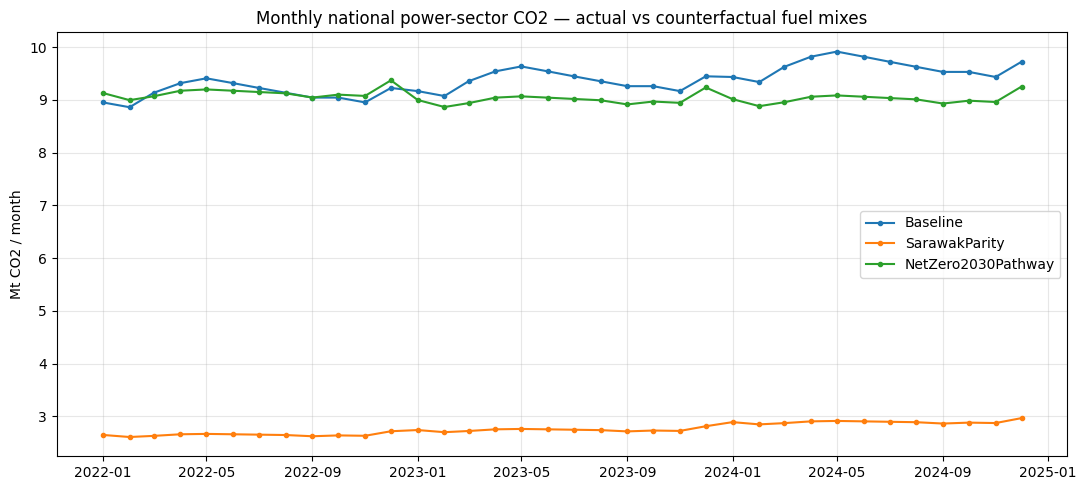

In [5]:
# Monthly national emissions, all three scenarios.
fig, ax = plt.subplots(figsize=(11, 5))
for s in SCENARIOS:
    d = monthly[monthly.scenario == s].sort_values("date")
    ax.plot(d["date"], d["co2_mt"], marker="o", ms=3, label=s)
ax.set_title("Monthly national power-sector CO2 — actual vs counterfactual fuel mixes")
ax.set_ylabel("Mt CO2 / month")
ax.set_xlabel("")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "counterfactual_monthly.png"), dpi=130)
print("wrote outputs/counterfactual_monthly.png")
plt.show()

wrote outputs/counterfactual_summary.png

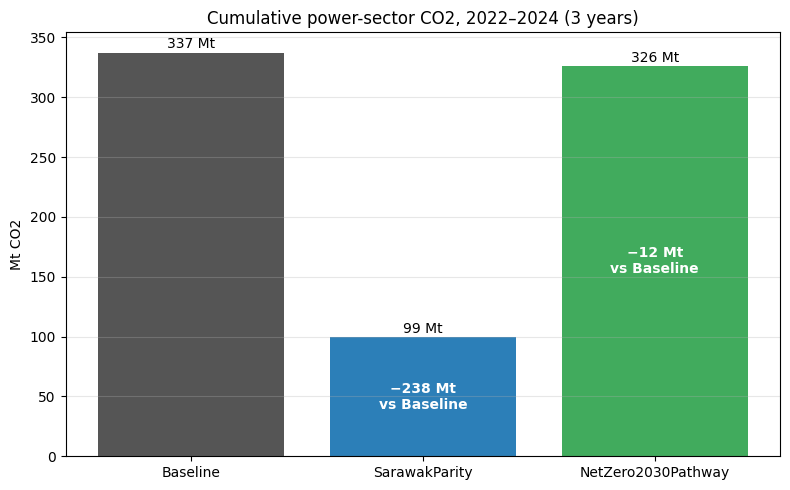

In [6]:
# Cumulative 2022-2024 emissions per scenario, with avoided-vs-Baseline deltas labelled.
cum = long.groupby("scenario")["co2_mt"].sum().reindex(SCENARIOS)
baseline_cum = cum["Baseline"]
avoided = baseline_cum - cum

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(SCENARIOS, cum.values, color=["#555555", "#2c7fb8", "#41ab5d"])
for b, s in zip(bars, SCENARIOS):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1,
            f"{cum[s]:.0f} Mt", ha="center", va="bottom", fontsize=10)
    if s != "Baseline":
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() / 2,
                f"−{avoided[s]:.0f} Mt\nvs Baseline", ha="center", va="center",
                fontsize=10, color="white", fontweight="bold")
ax.set_title("Cumulative power-sector CO2, 2022–2024 (3 years)")
ax.set_ylabel("Mt CO2")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(os.path.join(OUT, "counterfactual_summary.png"), dpi=130)
print("wrote outputs/counterfactual_summary.png")
plt.show()

In [7]:
# Summary table.
PRICE_TAX = 20.0   # RM/tonne -- projected starting rate, Malaysia 2026 carbon tax (iron/steel + energy)
PRICE_BCX = 50.0   # RM/tonne -- floor price, Bursa Carbon Exchange first nature-based auction (Jul 2024)

summary = pd.DataFrame({
    "cumulative_Mt_CO2": cum.round(1),
    "avoided_vs_Baseline_Mt": avoided.round(1),
    "avoided_value_RMbn_at_RM20": (avoided * 1e6 * PRICE_TAX / 1e9).round(2),
    "avoided_value_RMbn_at_RM50": (avoided * 1e6 * PRICE_BCX / 1e9).round(2),
})
print(summary.to_string())
print()
print(f"For reference, Baseline's own {baseline_cum:.0f} Mt over 3 years would carry a")
print(f"carbon-cost of RM {baseline_cum*1e6*PRICE_TAX/1e9:.1f} bn at RM20/t and "
      f"RM {baseline_cum*1e6*PRICE_BCX/1e9:.1f} bn at RM50/t.")
print()
print("Year-on-year national totals (Mt CO2):")
print(annual_wide.round(2).to_string())

                    cumulative_Mt_CO2  avoided_vs_Baseline_Mt  avoided_value_RMbn_at_RM20  avoided_value_RMbn_at_RM50
scenario                                                                                                             
Baseline                        337.4                     0.0                        0.00                        0.00
SarawakParity                    99.4                   238.0                        4.76                       11.90
NetZero2030Pathway              325.9                    11.5                        0.23                        0.58

For reference, Baseline's own 337 Mt over 3 years would carry a
carbon-cost of RM 6.7 bn at RM20/t and RM 16.9 bn at RM50/t.

Year-on-year national totals (Mt CO2):
scenario  Baseline  SarawakParity  NetZero2030Pathway
year                                                 
2022        109.63          31.78              109.61
2023        112.25          32.89              108.03
2024        115.53          

## Honesty caveats

This counterfactual deliberately holds generation constant and redistributes fuel mix.
It does NOT model:
- Capacity constraints (Peninsular cannot adopt Sarawak's hydro share without ~15 GW of new build)
- Transmission and storage costs of higher renewable penetration
- Demand response to electricity price changes
- Plant retirement schedules or capital costs of new build

The numbers represent an upper bound on what fuel-mix change alone could have achieved,
not a feasible policy pathway. They quantify the gap between the policy narrative and
the emissions reality — not a recommendation.

One more, specific to this dataset: the monthly grain is interpolated from official
annual totals with a seasonal adjustment; the `SarawakParity` and `NetZero2030Pathway`
mixes are stylised. Treat the monthly curves as illustrative of shape, the annual and
cumulative figures as the load-bearing numbers, and the avoided-emissions deltas as
order-of-magnitude, not precise.

## Appendix — can the fuel mix be predicted from demand and fuel prices?

A natural objection to the counterfactual above: maybe the mix isn't a free choice — maybe it
responds to demand and to relative fuel prices, so the observed path is roughly what those
drivers dictate. If so, a regression of the monthly coal share on demand, the coal price and
the gas price should fit well.

Two caveats before the numbers. First, the fuel-price series in this dataset is coarse — it is
constant within each calendar year — so over 36 months it carries little more than a year
label, and the coal and gas prices move together. Second, that is itself part of the answer: a
price-driven model of the mix has almost nothing to work with here, and would not have much
more in reality, because Malaysia's generation mix is set by which plants exist and their
dispatch order, not by month-to-month price moves.

In [8]:
import statsmodels.formula.api as smf

con = sqlite3.connect(DB)
nat = pd.read_sql_query(
    """
    SELECT d.year, d.month, d.month_start,
           SUM(CASE WHEN f.fuel_name = 'Coal' THEN g.mwh ELSE 0 END) AS coal_mwh,
           SUM(g.mwh) AS total_gen_mwh
    FROM fact_generation_monthly g
    JOIN dim_date_month d USING(date_id)
    JOIN dim_fuel f       USING(fuel_id)
    GROUP BY d.year, d.month, d.month_start
    """, con)
dem = pd.read_sql_query(
    "SELECT date_id, SUM(mwh_demand) AS demand_mwh FROM fact_demand_monthly GROUP BY date_id", con)
prc = pd.read_sql_query(
    """SELECT p.date_id, f.fuel_name, p.price_rm
       FROM fuel_price_monthly p JOIN dim_fuel f USING(fuel_id)
       WHERE f.fuel_name IN ('Coal', 'Gas')""", con)
dd = pd.read_sql_query("SELECT date_id, year, month FROM dim_date_month", con)
con.close()

prc = (prc.pivot(index="date_id", columns="fuel_name", values="price_rm")
          .rename(columns={"Coal": "coal_price", "Gas": "gas_price"}).reset_index())
nat = (nat.merge(dd, on=["year", "month"]).merge(dem, on="date_id").merge(prc, on="date_id")
          .sort_values(["year", "month"]).reset_index(drop=True))
nat["coal_share"] = nat["coal_mwh"] / nat["total_gen_mwh"]
print(f"{len(nat)} monthly observations; coal share ranges {nat.coal_share.min():.3f}-{nat.coal_share.max():.3f}")
nat[["year", "month", "coal_share", "demand_mwh", "coal_price", "gas_price"]].head()

36 monthly observations; coal share ranges 0.589-0.661


,year,month,coal_share,demand_mwh,coal_price,gas_price
0,2022,1,0.633323,12688134.0,350.0,420.0
1,2022,2,0.636315,12558663.0,350.0,420.0
2,2022,3,0.650653,12947075.0,350.0,420.0
3,2022,4,0.656088,13206016.0,350.0,420.0
4,2022,5,0.660747,13335487.0,350.0,420.0


In [9]:
# Levels: coal share ~ demand + coal price + gas price
m_lvl = smf.ols("coal_share ~ demand_mwh + coal_price + gas_price", data=nat).fit()
print("LEVELS  (n = %d)" % int(m_lvl.nobs))
print("  R^2 = %.3f   adj R^2 = %.3f" % (m_lvl.rsquared, m_lvl.rsquared_adj))
print("  coefficients (p-values):")
for name in m_lvl.params.index:
    print("    %-14s %+.3e   (p = %.3f)" % (name, m_lvl.params[name], m_lvl.pvalues[name]))

# First differences -- strip the trend. d_coal_price / d_gas_price are zero for almost every
# month-to-month transition (prices are year-constant), so the only regressor with genuine
# within-year variation is d_demand.
d = nat[["coal_share", "demand_mwh", "coal_price", "gas_price"]].diff().dropna()
d.columns = ["d_coal_share", "d_demand", "d_coal_price", "d_gas_price"]
n_price_moves = int((d[["d_coal_price", "d_gas_price"]].abs().sum(axis=1) > 0).sum())
m_fd_dem = smf.ols("d_coal_share ~ d_demand", data=d).fit()
m_fd_all = smf.ols("d_coal_share ~ d_demand + d_coal_price + d_gas_price", data=d).fit()
print("\nFIRST DIFFERENCES  (n = %d;  the price changes are non-zero in only %d of those transitions)"
      % (int(m_fd_dem.nobs), n_price_moves))
print("  d_coal_share ~ d_demand                          : R^2 = %.3f" % m_fd_dem.rsquared)
print("  d_coal_share ~ d_demand + d_coal_price + d_gas_price : R^2 = %.3f" % m_fd_all.rsquared)

cp, gp = m_lvl.params["coal_price"], m_lvl.params["gas_price"]
print("\nVerdict (read this as a cautionary result, not a clean one):")
print(f"  The levels model fits almost perfectly -- R^2 = {m_lvl.rsquared:.2f} -- which sounds like a")
print(f"  vindication of the price story until you look at the coefficients: coal_price and")
print(f"  gas_price come out almost exactly equal and opposite ({cp:+.4f} vs {gp:+.4f}). That is the")
print("  collinearity signature of two regressors that are, in this dataset, little more than a")
print("  year label -- they proxy the downward trend, they don't measure a price response. Same")
print(f"  trap in first differences: adding the price changes lifts R^2 from {m_fd_dem.rsquared:.2f} to {m_fd_all.rsquared:.2f},")
print("  but only because d_coal_price flags exactly the two year-boundary months where the share")
print("  steps -- it's behaving as a dummy, not a driver. The one number the year-proxy can't")
print(f"  game is d_coal_share on d_demand alone: R^2 = {m_fd_dem.rsquared:.2f}. Strip the trend and the")
print("  month-to-month mix barely moves with the only thing that genuinely varies within a")
print("  year. A behavioural 'cheap gas displaces coal' story gets no support; the data looks")
print("  like a fixed fleet dispatched against load. Two lessons: model the constraint and the")
print("  load, not the fuel price; and be suspicious of a regressor -- like this coarse price")
print("  series -- that turns out to be 'time' in a costume.")

LEVELS  (n = 36)
  R^2 = 0.948   adj R^2 = 0.943
  coefficients (p-values):
    Intercept      +5.696e-02   (p = 0.320)
    demand_mwh     +2.930e-08   (p = 0.000)
    coal_price     -3.737e-03   (p = 0.000)
    gas_price      +3.614e-03   (p = 0.000)

FIRST DIFFERENCES  (n = 35;  the price changes are non-zero in only 2 of those transitions)
  d_coal_share ~ d_demand                          : R^2 = 0.090
  d_coal_share ~ d_demand + d_coal_price + d_gas_price : R^2 = 0.767

Verdict (read this as a cautionary result, not a clean one):
  The levels model fits almost perfectly -- R^2 = 0.95 -- which sounds like a
  vindication of the price story until you look at the coefficients: coal_price and
  gas_price come out almost exactly equal and opposite (-0.0037 vs +0.0036). That is the
  collinearity signature of two regressors that are, in this dataset, little more than a
  year label -- they proxy the downward trend, they don't measure a price response. Same
  trap in first differences: a